# Energy Costs and Egg Price Shocks
### DS 440 Team 1 - Energy Covariate Analysis

> After removing trend/seasonality/AR(1) from egg prices, can energy costs explain the residual shocks?

**Series used:**
- Henry Hub Spot Price (MHHNGSP): monthly $/MMBtu, commodity market price
- Natural Gas PPI (WPU0531): BLS producer price index, smoother, preferred for regression

**Why energy matters:** Muhammad et al. (2023) found feed, HPAI, and natural gas each contributed roughly equally to the 2022 spike.

**Steps:** 1) Raw data 2) Baseline + residuals 3) Cross-correlation 4) Episode characterization 5) Timeline overlay 6) Precursor flags 7) Export

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.ar_model import AutoReg
import urllib.request, io, warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':'--','font.size':11})

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/Shareddrives/DS 440 Team 1/data/MHHNGSP.csv')
print(df.columns.tolist())
print(df.head(3))

['observation_date', 'MHHNGSP']
  observation_date  MHHNGSP
0       1997-01-01     3.45
1       1997-02-01     2.15
2       1997-03-01     1.89


In [ ]:
egg = (pd.read_csv('/content/drive/Shareddrives/DS 440 Team 1/data/APU0000708111.csv',
                   parse_dates=['observation_date'])
         .rename(columns={'observation_date':'date','APU0000708111':'egg_price'})
         .set_index('date').asfreq('MS'))

henryhub = (pd.read_csv('/content/drive/Shareddrives/DS 440 Team 1/data/MHHNGSP.csv',
                        parse_dates=['observation_date'])
              .rename(columns={'observation_date':'date','MHHNGSP':'gas_spot'})
              .set_index('date').asfreq('MS'))
henryhub['gas_spot'] = pd.to_numeric(henryhub['gas_spot'], errors='coerce')

gasppi = (pd.read_csv('/content/drive/Shareddrives/DS 440 Team 1/data/WPU0531.csv',
                      parse_dates=['observation_date'])
            .rename(columns={'observation_date':'date','WPU0531':'gas_ppi'})
            .set_index('date').asfreq('MS'))
gasppi['gas_ppi'] = pd.to_numeric(gasppi['gas_ppi'], errors='coerce')

start = '1997-01-01'
egg      = egg.loc[start:].interpolate()
henryhub = henryhub.loc[start:].interpolate()
gasppi   = gasppi.loc[start:].interpolate()

print('Window:', start, 'to', egg.index.max().date())
print('  Egg:      ', len(egg), 'obs')
print('  Henry Hub:', len(henryhub), 'obs')
print('  Gas PPI:  ', len(gasppi), 'obs')

Window: 1997-01-01 to 2026-02-01
  Egg:       350 obs
  Henry Hub: 351 obs
  Gas PPI:   351 obs


---
## Step 1 - Raw data

Key things to notice:
- Both series are **highly volatile** compared to feed -- natural gas is a traded commodity with sharp seasonal swings and geopolitical sensitivity
- Major energy spikes: 2000-01 (CA crisis), 2005 (Katrina/Rita), 2008 (commodity boom), 2022 (Ukraine war)
- Strong **seasonal pattern**: gas is expensive in winter, so seasonal dummies absorb more variance here than in the feed notebook
- The 2022 episode is critical: Henry Hub hit multi-decade highs while HPAI was devastating flocks -- compressing margins from both sides simultaneously

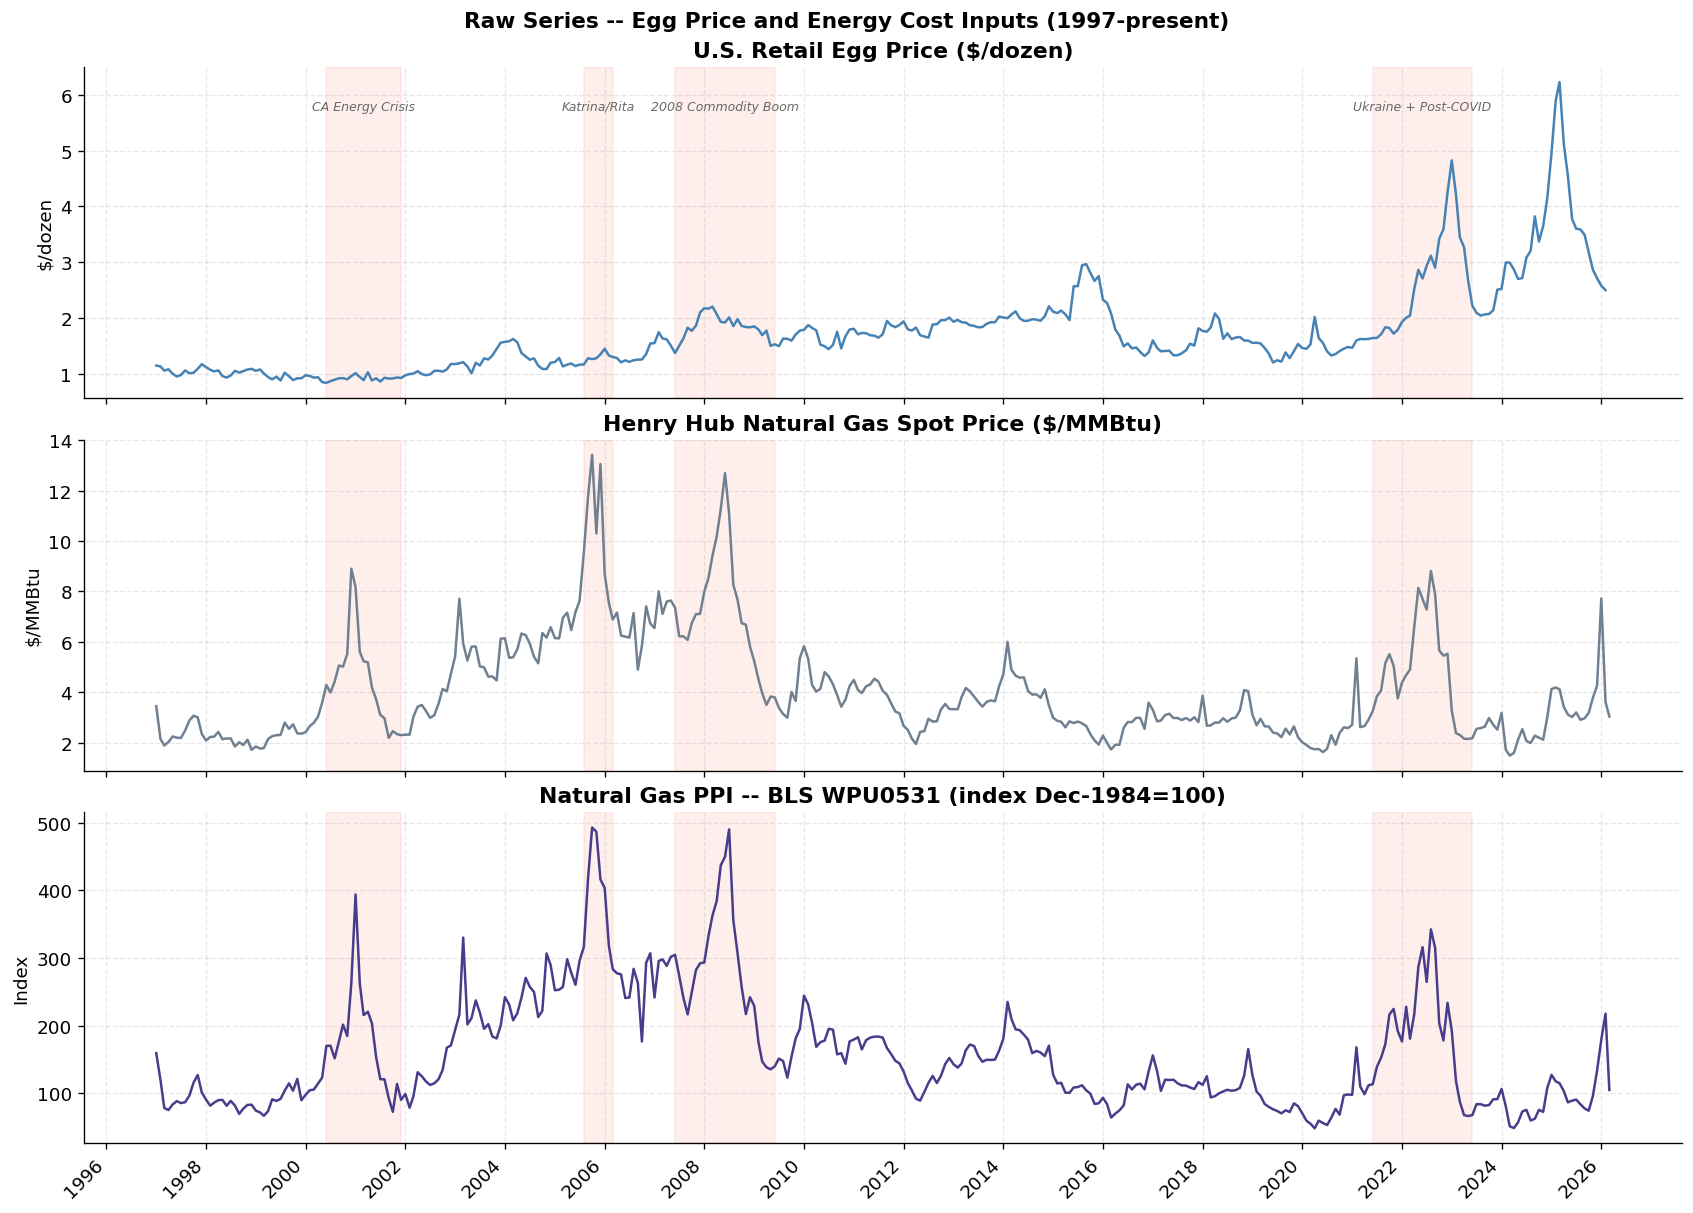

Look for persistent elevated energy periods that precede egg price spikes.


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)

axes[0].plot(egg.index,      egg['egg_price'],    color='steelblue',     lw=1.5)
axes[0].set_title('U.S. Retail Egg Price ($/dozen)', fontweight='bold')
axes[0].set_ylabel('$/dozen')

axes[1].plot(henryhub.index, henryhub['gas_spot'], color='slategray',    lw=1.5)
axes[1].set_title('Henry Hub Natural Gas Spot Price ($/MMBtu)', fontweight='bold')
axes[1].set_ylabel('$/MMBtu')

axes[2].plot(gasppi.index,   gasppi['gas_ppi'],    color='darkslateblue', lw=1.5)
axes[2].set_title('Natural Gas PPI -- BLS WPU0531 (index Dec-1984=100)', fontweight='bold')
axes[2].set_ylabel('Index')

epis = [
    ('2000-06-01', '2001-12-01', 'CA Energy Crisis'),
    ('2005-08-01', '2006-03-01', 'Katrina/Rita'),
    ('2007-06-01', '2009-06-01', '2008 Commodity Boom'),
    ('2021-06-01', '2023-06-01', 'Ukraine + Post-COVID'),
]
for ax in axes:
    for s, e, _ in epis:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.10, color='tomato')

ly = egg['egg_price'].max() * 0.92
for s, e, label in epis:
    mid = pd.Timestamp(s) + (pd.Timestamp(e) - pd.Timestamp(s)) / 2
    axes[0].text(mid, ly, label, ha='center', fontsize=7.5, color='dimgray', style='italic')

axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.suptitle('Raw Series -- Egg Price and Energy Cost Inputs (1997-present)',
             fontsize=13, fontweight='bold')
plt.show()
print('Look for persistent elevated energy periods that precede egg price spikes.')

---
## Step 2 - Fit baseline, extract residuals

Identical pipeline to feed_egg_shocks: AR(1) + monthly seasonality on log prices, predictive walk-forward residuals.

Key difference vs feed: gas has strong seasonal patterns (winter heating demand). Seasonal dummies absorb more variance, so residuals look cleaner than the raw series suggests.

In [ ]:
def fit_baseline_predictive(series, name, train_window=120):
    """
    Identical to feed_egg_shocks.ipynb:
    Train AR(1)+seasonal on first train_window months, walk-forward predict,
    rolling z-score (no rolling mean subtraction -- matches roz_khao_andey).
    """
    s = np.log(series.dropna())
    mdum = pd.get_dummies(s.index.month, prefix='m', drop_first=True).astype(int)
    mdum.index = s.index

    model = AutoReg(s.iloc[:train_window], lags=1, exog=mdum.iloc[:train_window]).fit()
    phi, const = model.params[1], model.params[0]

    preds, res = [], []
    for t in range(train_window, len(s)):
        month = s.index[t].month
        seas  = model.params['m_' + str(month)] if month != 1 else 0.0
        pred  = const + phi * s.iloc[t-1] + seas
        preds.append(pred)
        res.append(s.iloc[t] - pred)

    preds = pd.Series(preds, index=s.index[train_window:])
    res   = pd.Series(res,   index=s.index[train_window:])
    z     = res / res.rolling(12, min_periods=12).std()
    d     = pd.DataFrame({'log_val':s.iloc[train_window:], 'baseline':preds,
                          'residual':res, 'z_rolling':z})
    print(name + ': phi=' + str(round(phi,5)) + '  res_std=' + str(round(res.std(),5)) +
          '  train=' + str(s.index[0].date()) + ' to ' + str(s.index[train_window-1].date()))
    return d

egg_d = fit_baseline_predictive(egg['egg_price'],      'Egg Price')
hub_d = fit_baseline_predictive(henryhub['gas_spot'],  'Henry Hub Spot')
ppi_d = fit_baseline_predictive(gasppi['gas_ppi'],     'Natural Gas PPI')

Egg Price: phi=0.96656  res_std=0.07936  train=1997-01-01 to 2006-12-01
Henry Hub Spot: phi=0.96352  res_std=0.16569  train=1997-01-01 to 2006-12-01
Natural Gas PPI: phi=0.95644  res_std=0.16534  train=1997-01-01 to 2006-12-01


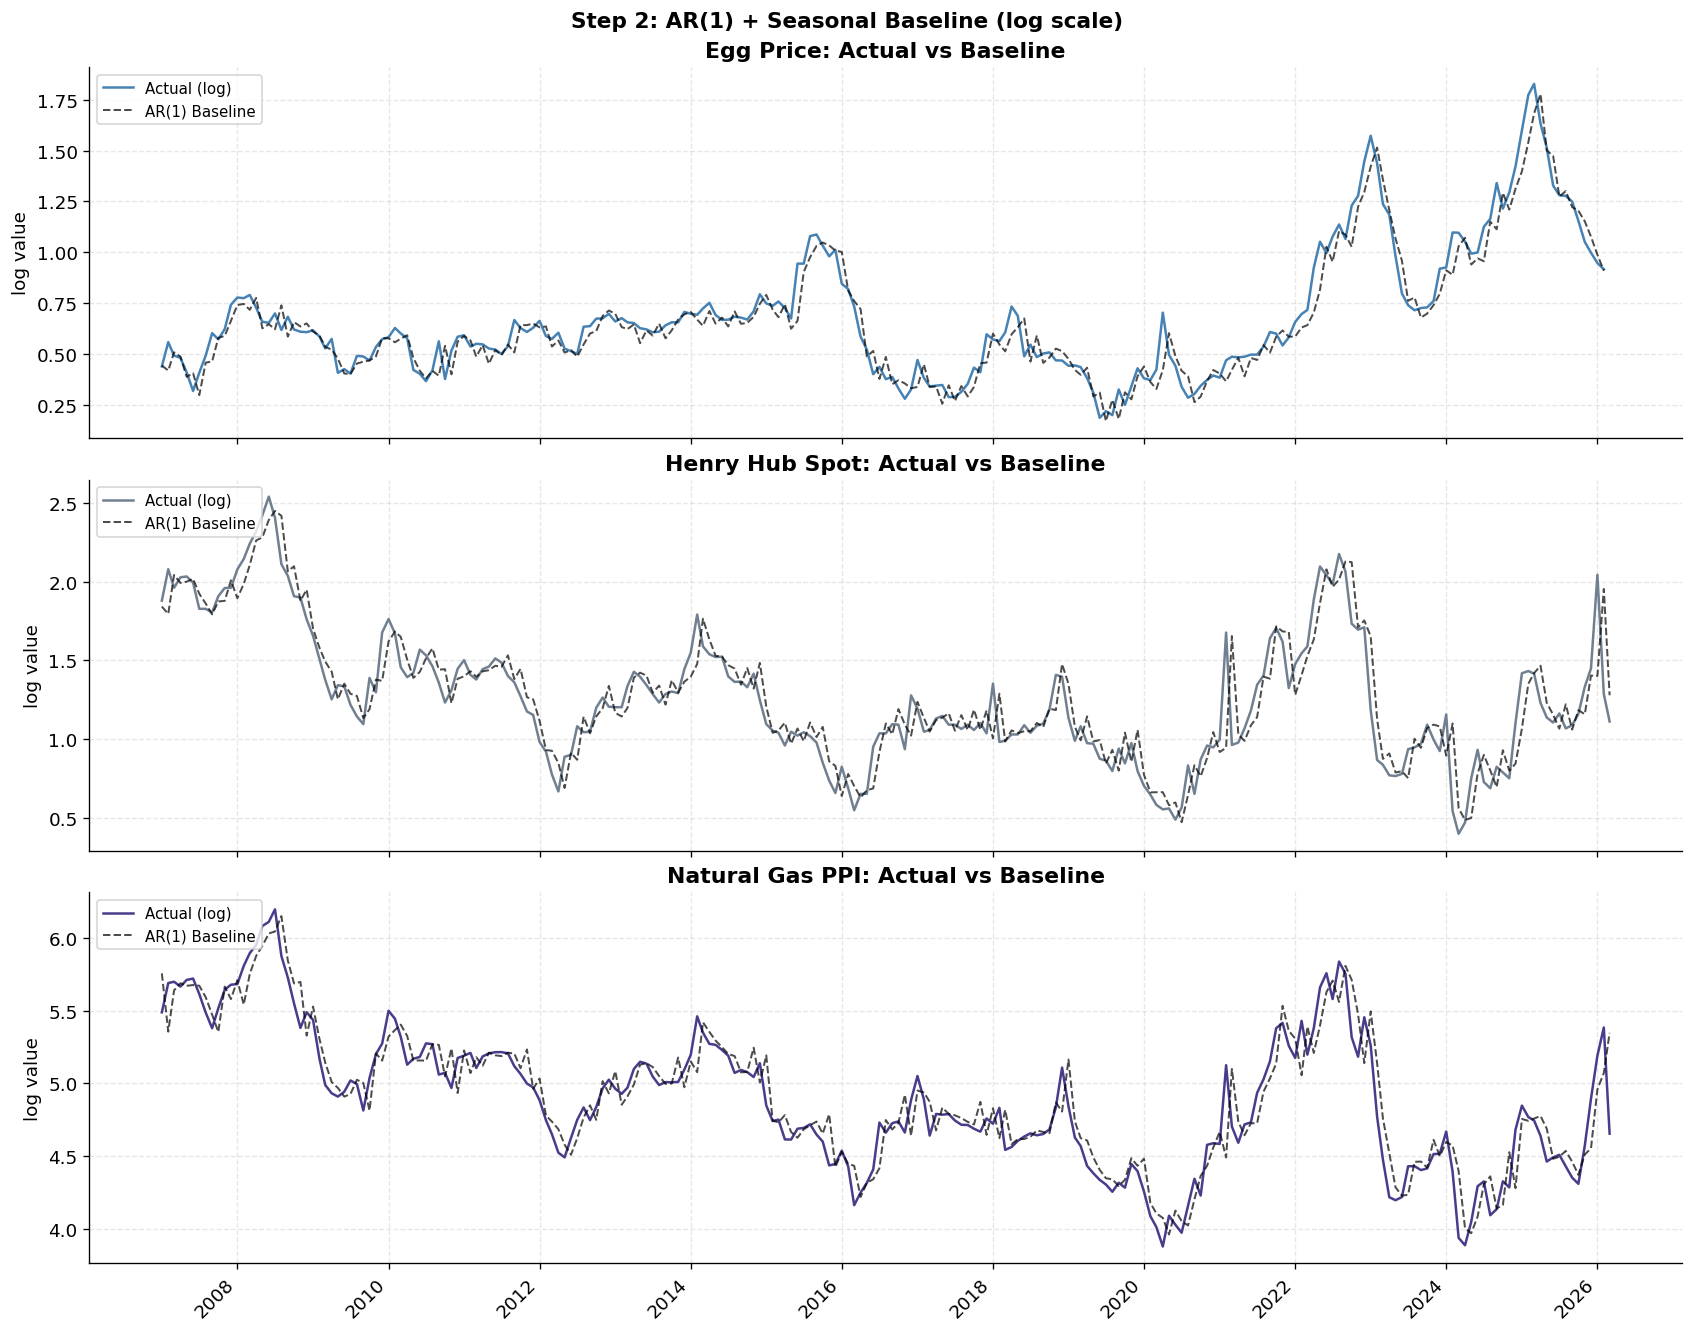

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True, constrained_layout=True)
for ax, d, name, color in [
    (axes[0], egg_d, 'Egg Price',       'steelblue'),
    (axes[1], hub_d, 'Henry Hub Spot',  'slategray'),
    (axes[2], ppi_d, 'Natural Gas PPI', 'darkslateblue'),
]:
    ax.plot(d.index, d['log_val'],  color=color,  lw=1.5, label='Actual (log)')
    ax.plot(d.index, d['baseline'], color='black', lw=1.2, ls='--', alpha=0.7, label='AR(1) Baseline')
    ax.set_title(name + ': Actual vs Baseline', fontweight='bold')
    ax.set_ylabel('log value')
    ax.legend(fontsize=9, loc='upper left')
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.suptitle('Step 2: AR(1) + Seasonal Baseline (log scale)', fontsize=13, fontweight='bold')
plt.show()

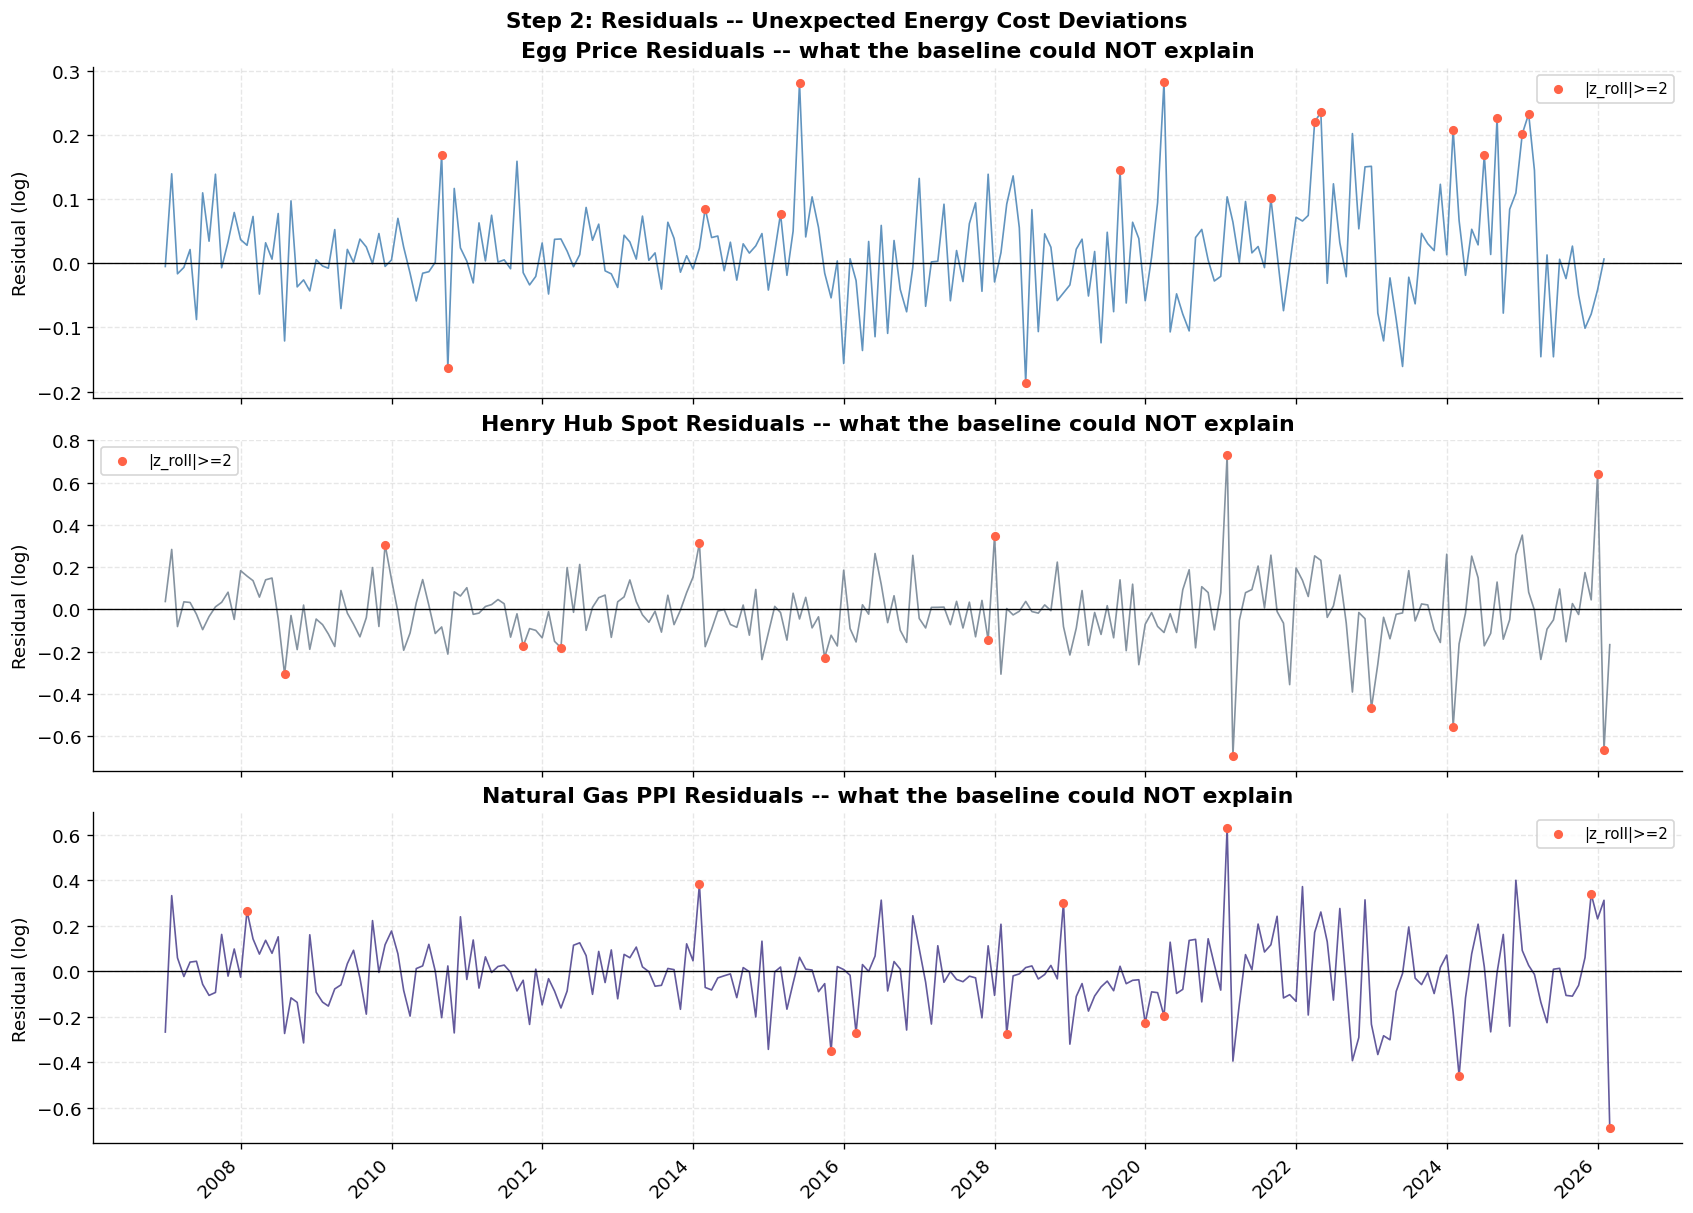

Henry Hub residuals are noisier -- spot price = commodity market.
Gas PPI residuals are smoother -- producer-facing index. Better for regression.
Look for energy spikes clustering in the same years as egg price spikes.


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
for ax, d, name, color in [
    (axes[0], egg_d, 'Egg Price',       'steelblue'),
    (axes[1], hub_d, 'Henry Hub Spot',  'slategray'),
    (axes[2], ppi_d, 'Natural Gas PPI', 'darkslateblue'),
]:
    sh = d['z_rolling'].abs() >= 2
    ax.plot(d.index, d['residual'], color=color, lw=1, alpha=0.85)
    ax.scatter(d.index[sh], d.loc[sh,'residual'], color='tomato', s=20, zorder=5, label='|z_roll|>=2')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(name + ' Residuals -- what the baseline could NOT explain', fontweight='bold')
    ax.set_ylabel('Residual (log)')
    ax.legend(fontsize=9)
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.suptitle('Step 2: Residuals -- Unexpected Energy Cost Deviations', fontsize=13, fontweight='bold')
plt.show()
print('Henry Hub residuals are noisier -- spot price = commodity market.')
print('Gas PPI residuals are smoother -- producer-facing index. Better for regression.')
print('Look for energy spikes clustering in the same years as egg price spikes.')

---
## Step 3 - Do energy shocks lead egg shocks?

Cross-correlate each energy residual against egg residuals at lags 0-18 months.
Peak at k>0 means energy spikes k months before egg prices.

**vs feed:** feed passthrough ~1-6 months (Leibtag 2009). Energy could be faster (immediate heating bills) or slower (producers hedge). The 2022 episode suggests energy may be contemporaneous -- both driven simultaneously by Ukraine war.

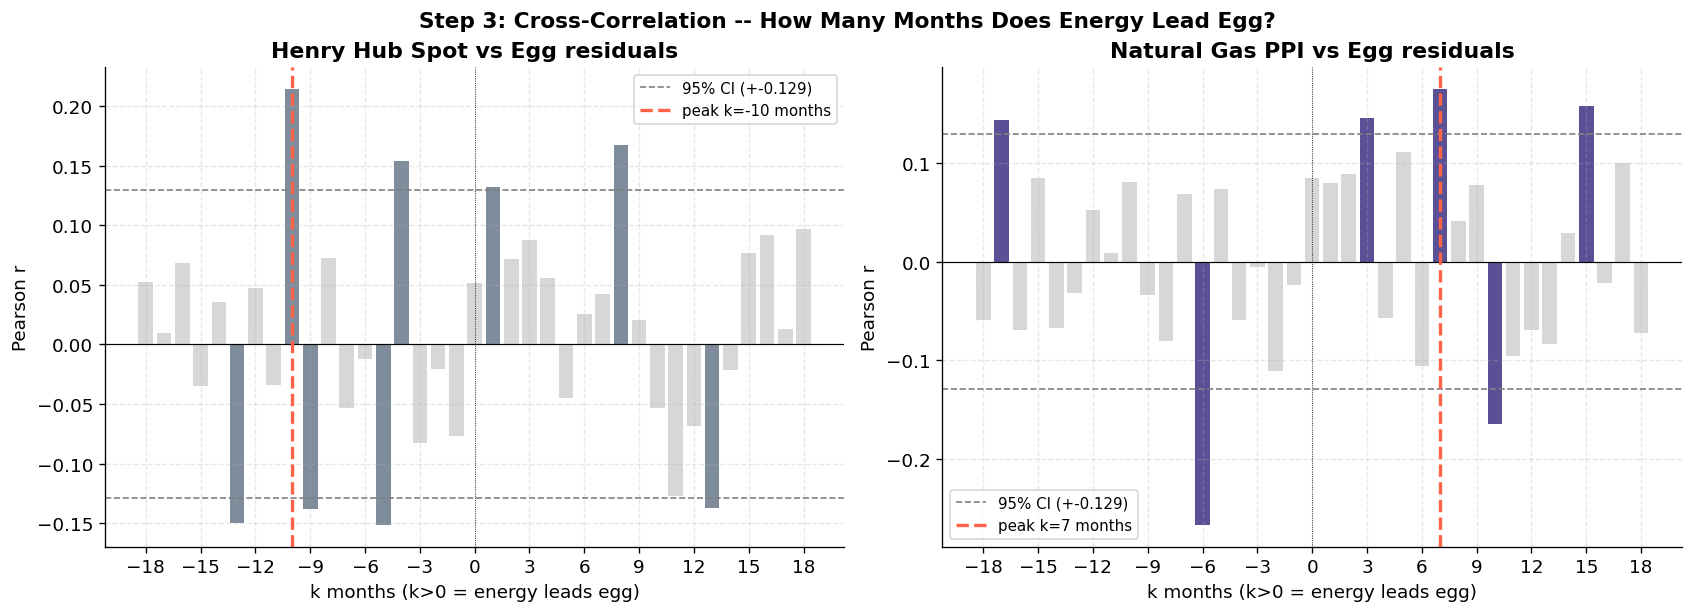

Henry Hub peak lag: k=-10 months  (r=0.214)
Gas PPI peak lag:   k=7 months  (r=0.175)
k=0 => contemporaneous | k>0 => energy leads | k<0 => egg leads (unusual)
Compare to feed lag: if energy lag < feed lag, energy passes through faster.


In [ ]:
common = egg_d.index.intersection(hub_d.index).intersection(ppi_d.index)
egg_r  = egg_d.loc[common, 'residual']
hub_r  = hub_d.loc[common, 'residual']
ppi_r  = ppi_d.loc[common, 'residual']

max_lag = 18
lags    = list(range(-max_lag, max_lag + 1))
ccf_hub = [hub_r.corr(egg_r.shift(-k)) for k in lags]
ccf_ppi = [ppi_r.corr(egg_r.shift(-k)) for k in lags]
ci      = 1.96 / np.sqrt(len(common))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, ccf, name, color in [
    (axes[0], ccf_hub, 'Henry Hub Spot',  'slategray'),
    (axes[1], ccf_ppi, 'Natural Gas PPI', 'darkslateblue'),
]:
    bc = [color if abs(v) > ci else 'lightgray' for v in ccf]
    ax.bar(lags, ccf, color=bc, width=0.8, alpha=0.9)
    ax.axhline( ci, color='gray', ls='--', lw=1)
    ax.axhline(-ci, color='gray', ls='--', lw=1, label='95% CI (+-' + str(round(ci,3)) + ')')
    ax.axhline(0, color='black', lw=0.7)
    ax.axvline(0, color='black', lw=0.5, ls=':')
    pk = lags[np.argmax(ccf)]
    ax.axvline(pk, color='tomato', lw=2, ls='--', label='peak k=' + str(pk) + ' months')
    ax.set_title(name + ' vs Egg residuals', fontweight='bold')
    ax.set_xlabel('k months (k>0 = energy leads egg)')
    ax.set_ylabel('Pearson r')
    ax.legend(fontsize=9)
    ax.set_xticks(range(-max_lag, max_lag+1, 3))
plt.suptitle('Step 3: Cross-Correlation -- How Many Months Does Energy Lead Egg?',
             fontsize=13, fontweight='bold')
plt.show()
ph = lags[np.argmax(ccf_hub)]
pp = lags[np.argmax(ccf_ppi)]
print('Henry Hub peak lag: k=' + str(ph) + ' months  (r=' + str(round(max(ccf_hub),3)) + ')')
print('Gas PPI peak lag:   k=' + str(pp) + ' months  (r=' + str(round(max(ccf_ppi),3)) + ')')
print('k=0 => contemporaneous | k>0 => energy leads | k<0 => egg leads (unusual)')
print('Compare to feed lag: if energy lag < feed lag, energy passes through faster.')

---
## Step 4 - Shock episode characterization

For each egg price episode: ramp-up time, decay time, asymmetry (rockets and feathers?), energy precursor.
Also characterize energy episodes themselves -- energy shocks tend to be shorter and sharper than feed shocks.

In [ ]:
def get_episodes(z, threshold=2.0, gap=3):
    sd = z.index[z.abs() >= threshold].tolist()
    if not sd:
        return []
    eps, cur = [], [sd[0]]
    for d in sd[1:]:
        mg = (d.year - cur[-1].year) * 12 + d.month - cur[-1].month
        if mg <= gap:
            cur.append(d)
        else:
            eps.append(cur)
            cur = [d]
    eps.append(cur)
    rows = []
    for ep in eps:
        pi = z.loc[ep].abs().idxmax()
        rows.append({
            'start':       ep[0],
            'peak':        pi,
            'end':         ep[-1],
            'peak_z':      round(z.loc[pi], 2),
            'direction':   'UP' if z.loc[pi] > 0 else 'DOWN',
            'duration_mo': len(ep),
            'ramp_up_mo':  (pi.year - ep[0].year)*12 + pi.month - ep[0].month,
            'decay_mo':    (ep[-1].year - pi.year)*12 + ep[-1].month - pi.month,
        })
    return rows

egg_ep_df = pd.DataFrame(get_episodes(egg_d['z_rolling']))
hub_ep_df = pd.DataFrame(get_episodes(hub_d['z_rolling']))
ppi_ep_df = pd.DataFrame(get_episodes(ppi_d['z_rolling']))

evt = {
    2000:'CA Energy Crisis', 2001:'CA Energy Crisis',
    2005:'Katrina/Rita', 2008:'Global commodity boom',
    2009:'Post-crisis collapse', 2012:'Drought/commodity',
    2014:'HPAI 2014-15', 2015:'HPAI 2014-15',
    2021:'Post-COVID+Ukraine', 2022:'Ukraine+HPAI+energy',
}
egg_ep_df['event'] = egg_ep_df['start'].apply(
    lambda d: evt.get(d.year, evt.get(d.year-1, '---')))

print('=== Egg Price Shock Episodes ===')
print(egg_ep_df[['start','peak','end','direction','peak_z',
                  'duration_mo','ramp_up_mo','decay_mo','event']].to_string(index=False))
print()
print('=== Henry Hub Shock Episodes ===')
if len(hub_ep_df):
    print(hub_ep_df[['start','peak','end','direction','peak_z','duration_mo']].to_string(index=False))
print()
print('=== Natural Gas PPI Shock Episodes ===')
if len(ppi_ep_df):
    print(ppi_ep_df[['start','peak','end','direction','peak_z','duration_mo']].to_string(index=False))

=== Egg Price Shock Episodes ===
     start       peak        end direction  peak_z  duration_mo  ramp_up_mo  decay_mo                event
2010-09-01 2010-09-01 2010-10-01        UP    2.93            2           0         1 Post-crisis collapse
2014-03-01 2014-03-01 2014-03-01        UP    2.28            1           0         0         HPAI 2014-15
2015-03-01 2015-06-01 2015-06-01        UP    3.40            2           3         0         HPAI 2014-15
2018-06-01 2018-06-01 2018-06-01      DOWN   -2.03            1           0         0                  ---
2019-09-01 2019-09-01 2019-09-01        UP    2.04            1           0         0                  ---
2020-04-01 2020-04-01 2020-04-01        UP    2.56            1           0         0                  ---
2021-09-01 2021-09-01 2021-09-01        UP    2.12            1           0         0   Post-COVID+Ukraine
2022-04-01 2022-04-01 2022-05-01        UP    3.00            2           0         1  Ukraine+HPAI+energy
2024

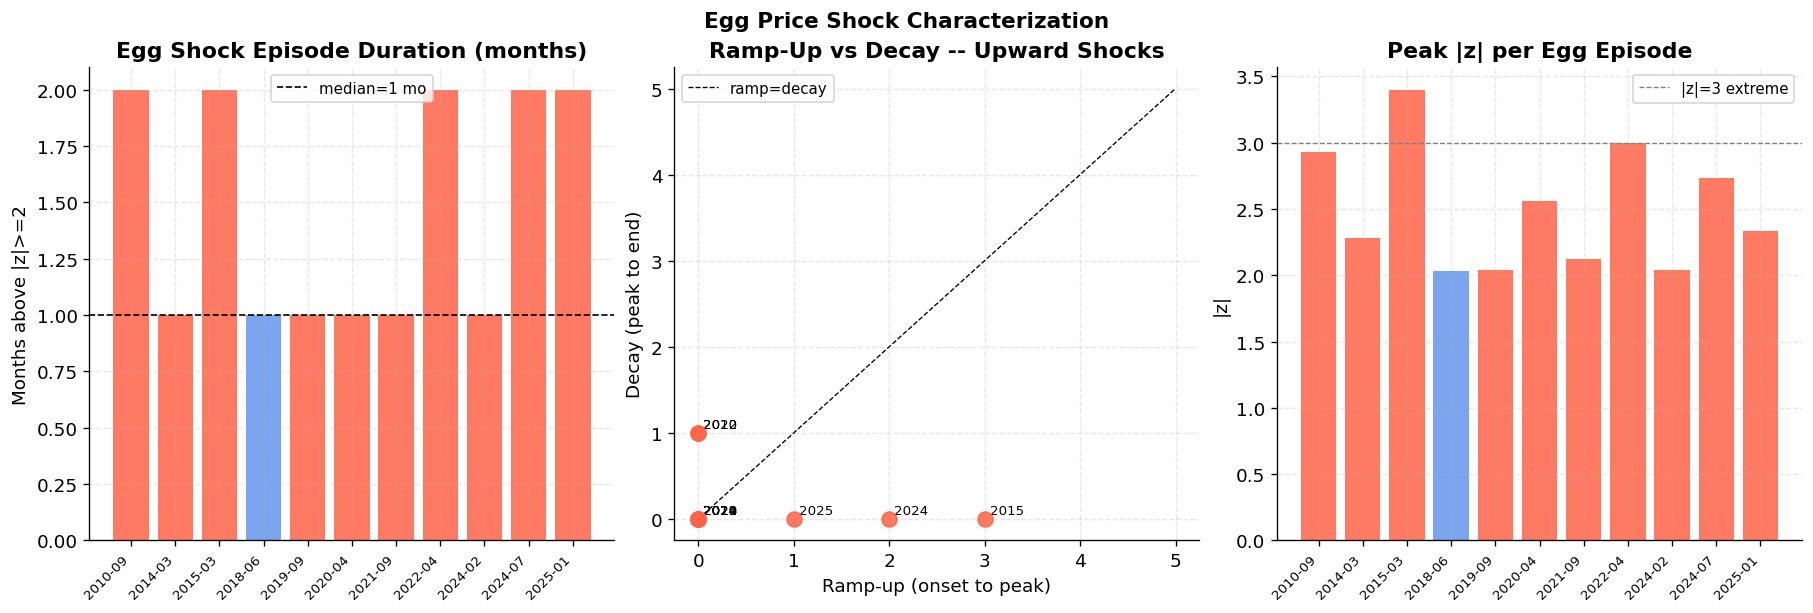

Median egg episode: 1 months
Avg ramp-up: 0.6 mo | Avg decay: 0.2 mo | Asymmetry: 0.4 mo
Recovers faster than spikes
Henry Hub: 11 episodes, median 1 mo
Gas PPI:   10 episodes, median 1 mo
Shorter energy episodes => producers absorb transient spikes; sustained shocks pass through.


In [ ]:
up = egg_ep_df[egg_ep_df['direction'] == 'UP'].copy()
ec = ['tomato' if d == 'UP' else 'cornflowerblue' for d in egg_ep_df['direction']]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

med = egg_ep_df['duration_mo'].median()
axes[0].bar(range(len(egg_ep_df)), egg_ep_df['duration_mo'], color=ec, alpha=0.85)
axes[0].set_xticks(range(len(egg_ep_df)))
axes[0].set_xticklabels([d.strftime('%Y-%m') for d in egg_ep_df['start']],
                         rotation=45, ha='right', fontsize=8)
axes[0].set_title('Egg Shock Episode Duration (months)', fontweight='bold')
axes[0].set_ylabel('Months above |z|>=2')
axes[0].axhline(med, color='black', ls='--', lw=1,
                label='median=' + str(int(med)) + ' mo')
axes[0].legend(fontsize=9)

if len(up) > 0:
    axes[1].scatter(up['ramp_up_mo'], up['decay_mo'], s=80, color='tomato', alpha=0.85, zorder=5)
    for _, row in up.iterrows():
        axes[1].annotate(row['start'].strftime('%Y'), (row['ramp_up_mo'], row['decay_mo']),
                         fontsize=8, ha='left', xytext=(3,3), textcoords='offset points')
    lim = max(up['ramp_up_mo'].max(), up['decay_mo'].max()) + 2
    axes[1].plot([0, lim], [0, lim], 'k--', lw=0.8, label='ramp=decay')
    axes[1].set_title('Ramp-Up vs Decay -- Upward Shocks', fontweight='bold')
    axes[1].set_xlabel('Ramp-up (onset to peak)')
    axes[1].set_ylabel('Decay (peak to end)')
    axes[1].legend(fontsize=9)

axes[2].bar(range(len(egg_ep_df)), egg_ep_df['peak_z'].abs(), color=ec, alpha=0.85)
axes[2].set_xticks(range(len(egg_ep_df)))
axes[2].set_xticklabels([d.strftime('%Y-%m') for d in egg_ep_df['start']],
                         rotation=45, ha='right', fontsize=8)
axes[2].axhline(3, color='gray', ls='--', lw=0.8, label='|z|=3 extreme')
axes[2].set_title('Peak |z| per Egg Episode', fontweight='bold')
axes[2].set_ylabel('|z|')
axes[2].legend(fontsize=9)

plt.suptitle('Egg Price Shock Characterization', fontsize=13, fontweight='bold')
plt.show()

print('Median egg episode:', int(egg_ep_df['duration_mo'].median()), 'months')
if len(up) > 0:
    asym = up['ramp_up_mo'].mean() - up['decay_mo'].mean()
    print('Avg ramp-up:', round(up['ramp_up_mo'].mean(),1), 'mo | Avg decay:',
          round(up['decay_mo'].mean(),1), 'mo | Asymmetry:', round(asym,1), 'mo')
    print('Spikes faster than recovers' if asym < 0 else 'Recovers faster than spikes')
if len(hub_ep_df):
    print('Henry Hub: ' + str(len(hub_ep_df)) + ' episodes, median ' +
          str(int(hub_ep_df['duration_mo'].median())) + ' mo')
if len(ppi_ep_df):
    print('Gas PPI:   ' + str(len(ppi_ep_df)) + ' episodes, median ' +
          str(int(ppi_ep_df['duration_mo'].median())) + ' mo')
print('Shorter energy episodes => producers absorb transient spikes; sustained shocks pass through.')

---
## Step 5 - Full picture: overlay shock timelines

All three rolling z-scores. Red=above +2sigma, blue=below -2sigma.

Look for energy rows lighting up **before** the egg row. The 2022 episode is the critical test.

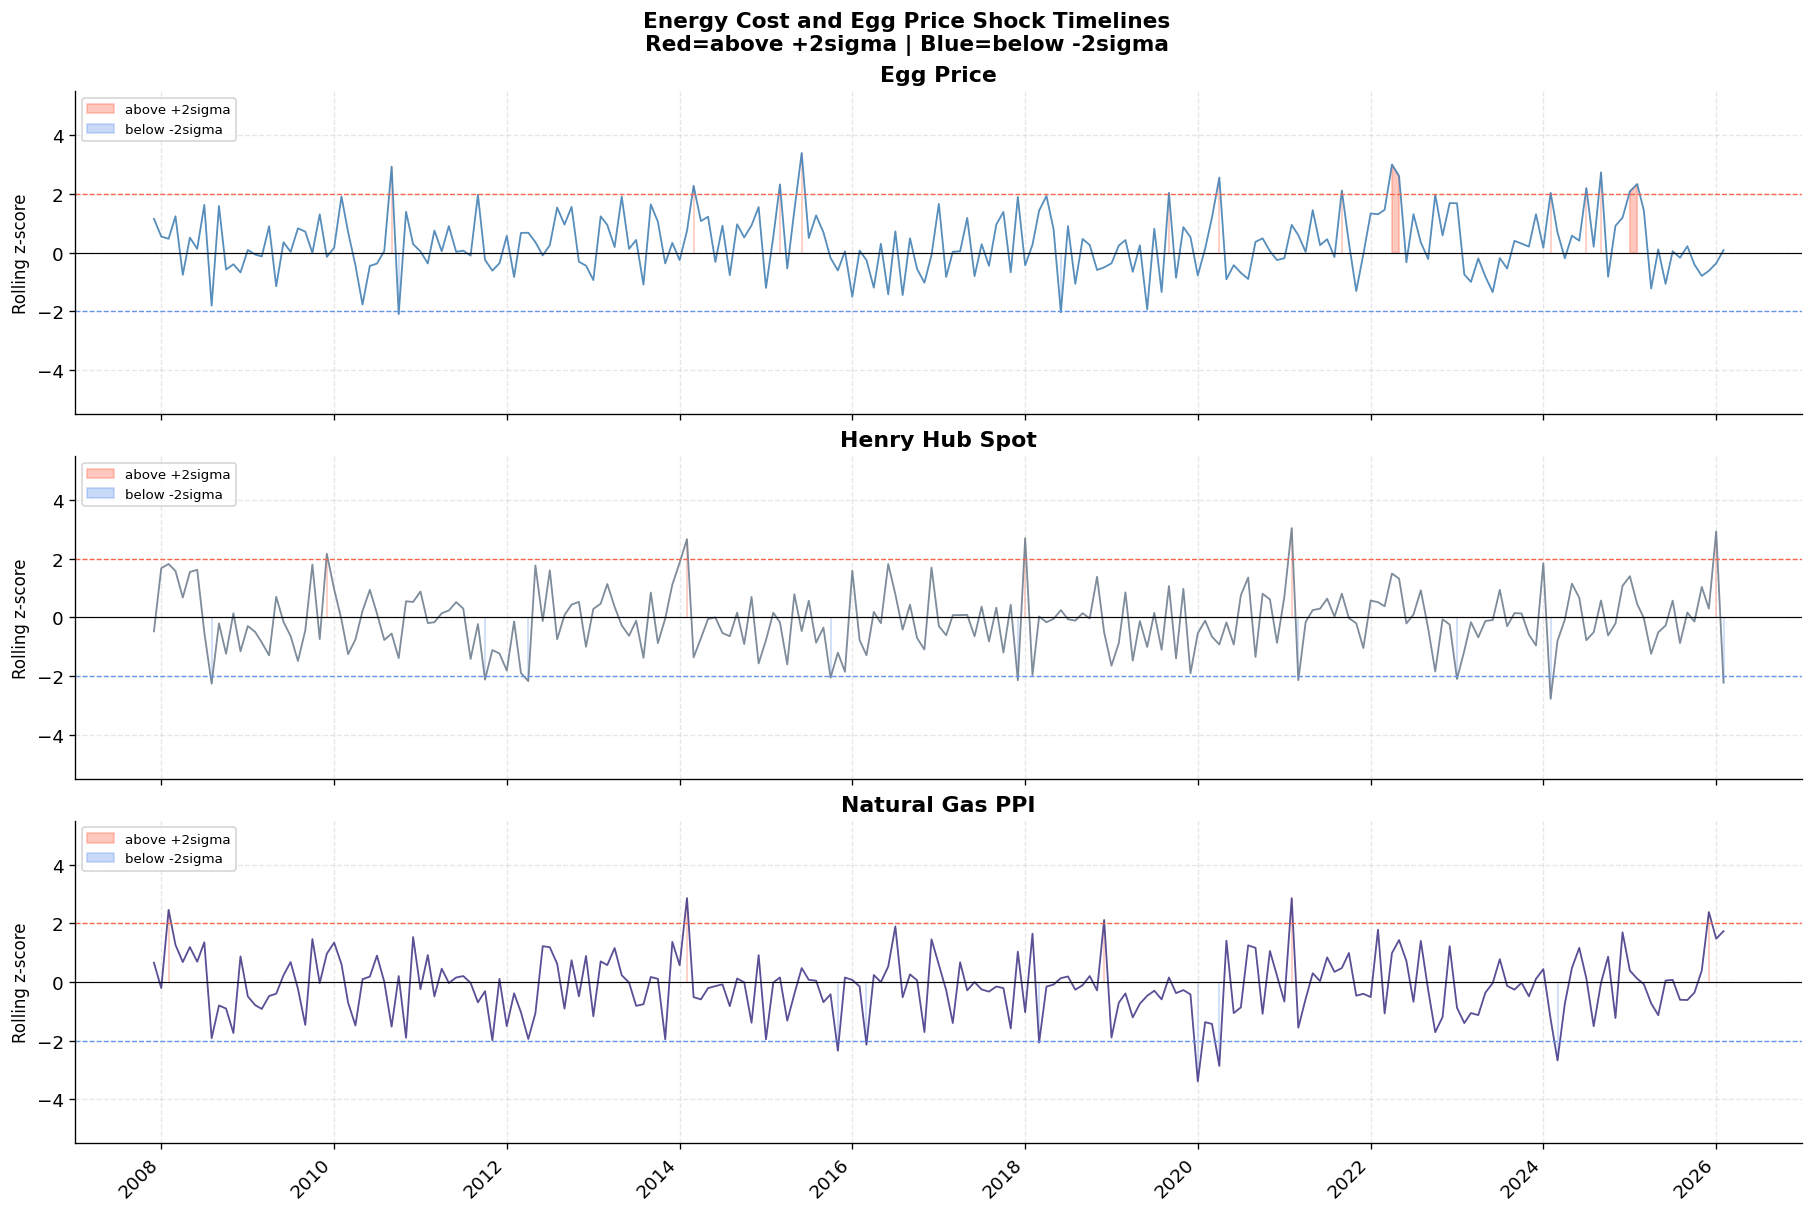

=> If energy rows turn red BEFORE egg row, energy is a likely upstream driver.
=> Look especially at 2000-01, 2005, 2008, 2021-22.
=> Gas PPI is smoother than Henry Hub -- fewer false positives, better for regression.


In [ ]:
common = egg_d.index.intersection(hub_d.index).intersection(ppi_d.index)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True, constrained_layout=True)

for ax, (d, name, color) in zip(axes, [
    (egg_d.loc[common], 'Egg Price',       'steelblue'),
    (hub_d.loc[common], 'Henry Hub Spot',  'slategray'),
    (ppi_d.loc[common], 'Natural Gas PPI', 'darkslateblue'),
]):
    z = d['z_rolling'].clip(-5, 5)
    ax.fill_between(d.index, z, 0, where=(z >  2), alpha=0.35, color='tomato',
                    label='above +2sigma')
    ax.fill_between(d.index, z, 0, where=(z < -2), alpha=0.35, color='cornflowerblue',
                    label='below -2sigma')
    ax.plot(d.index, z, color=color, lw=1.1, alpha=0.9)
    ax.axhline( 2, color='tomato',         lw=0.8, ls='--')
    ax.axhline(-2, color='cornflowerblue', lw=0.8, ls='--')
    ax.axhline( 0, color='black',          lw=0.7)
    ax.set_ylabel('Rolling z-score', fontsize=10)
    ax.set_title(name, fontweight='bold')
    ax.set_ylim(-5.5, 5.5)
    ax.legend(fontsize=8, loc='upper left')

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.suptitle('Energy Cost and Egg Price Shock Timelines\nRed=above +2sigma | Blue=below -2sigma',
             fontsize=13, fontweight='bold')
plt.show()
print('=> If energy rows turn red BEFORE egg row, energy is a likely upstream driver.')
print('=> Look especially at 2000-01, 2005, 2008, 2021-22.')
print('=> Gas PPI is smoother than Henry Hub -- fewer false positives, better for regression.')

---
## Step 6 - Did an energy shock precede each egg shock?

For each egg episode, look back 12 months for an energy shock. Gives a precursor flag equivalent to feed_precursor/corn_precursor in feed_egg_shocks.

In [ ]:
def had_precursor(ep_start, z_series, lookback=12, threshold=2.0):
    window = z_series.loc[ep_start - pd.DateOffset(months=lookback):ep_start]
    return bool((window.abs() >= threshold).any())

results = []
for _, ep in egg_ep_df.iterrows():
    results.append({
        'start':              ep['start'].strftime('%Y-%m'),
        'direction':          ep['direction'],
        'duration_mo':        ep['duration_mo'],
        'peak_z':             ep['peak_z'],
        'event':              ep['event'],
        'henryhub_precursor': 'Y' if had_precursor(ep['start'], hub_d['z_rolling']) else '---',
        'gasppi_precursor':   'Y' if had_precursor(ep['start'], ppi_d['z_rolling']) else '---',
    })

attr_df = pd.DataFrame(results)
print('=== Egg Episodes with Energy Precursor Check (12-month lookback) ===')
print(attr_df.to_string(index=False))
print()
nh  = (attr_df['henryhub_precursor'] == 'Y').sum()
np_ = (attr_df['gasppi_precursor']   == 'Y').sum()
print('Preceded by Henry Hub shock: ' + str(nh)  + '/' + str(len(attr_df)))
print('Preceded by Gas PPI shock:   ' + str(np_) + '/' + str(len(attr_df)))
print('If energy precursor rate < feed rate => energy secondary but real (Muhammad et al. 2023).')

=== Egg Episodes with Energy Precursor Check (12-month lookback) ===
  start direction  duration_mo  peak_z                event henryhub_precursor gasppi_precursor
2010-09        UP            2    2.93 Post-crisis collapse                  Y              ---
2014-03        UP            1    2.28         HPAI 2014-15                  Y                Y
2015-03        UP            2    3.40         HPAI 2014-15                ---              ---
2018-06      DOWN            1   -2.03                  ---                  Y                Y
2019-09        UP            1    2.04                  ---                ---                Y
2020-04        UP            1    2.56                  ---                ---                Y
2021-09        UP            1    2.12   Post-COVID+Ukraine                  Y                Y
2022-04        UP            2    3.00  Ukraine+HPAI+energy                ---              ---
2024-02        UP            1    2.04                  ---        

---
## Summary

In [ ]:
ph = lags[np.argmax(ccf_hub)]
pp = lags[np.argmax(ccf_ppi)]
print('=' * 65)
print('PROJECT QUESTIONS -- ANSWERS FROM THIS NOTEBOOK')
print('=' * 65)
print()
print('Q: What are the energy shocks?')
if len(hub_ep_df):
    print('   Henry Hub: ' + str(len(hub_ep_df)) + ' episodes, median ' +
          str(int(hub_ep_df['duration_mo'].median())) + ' mo')
if len(ppi_ep_df):
    print('   Gas PPI:   ' + str(len(ppi_ep_df)) + ' episodes, median ' +
          str(int(ppi_ep_df['duration_mo'].median())) + ' mo')
print()
print('Q: Do energy shocks lead egg price shocks?')
print('   Henry Hub peak lag: k=' + str(ph) + ' months  (r=' + str(round(max(ccf_hub),3)) + ')')
print('   Gas PPI peak lag:   k=' + str(pp) + ' months  (r=' + str(round(max(ccf_ppi),3)) + ')')
print()
print('Q: Which series for roz_khao_andey v3?')
print('   => Gas PPI (WPU0531): smoother, producer-facing, better regression residuals')
print('   => Use lag-1, consistent with feed covariate')
print()
print('Q: How does energy compare to feed?')
print('   => Muhammad et al. (2023): feed, HPAI, energy each ~1/3 of 2022 spike')
print()
print('Next: v3 in roz_khao_andey')
print('   pred = const + phi*y[t-1] + beta_m*month + beta_f*feed_res[t-1] + beta_g*gas_res[t-1]')

PROJECT QUESTIONS -- ANSWERS FROM THIS NOTEBOOK

Q: What are the energy shocks?
   Henry Hub: 11 episodes, median 1 mo
   Gas PPI:   10 episodes, median 1 mo

Q: Do energy shocks lead egg price shocks?
   Henry Hub peak lag: k=-10 months  (r=0.214)
   Gas PPI peak lag:   k=7 months  (r=0.175)

Q: Which series for roz_khao_andey v3?
   => Gas PPI (WPU0531): smoother, producer-facing, better regression residuals
   => Use lag-1, consistent with feed covariate

Q: How does energy compare to feed?
   => Muhammad et al. (2023): feed, HPAI, energy each ~1/3 of 2022 spike

Next: v3 in roz_khao_andey
   pred = const + phi*y[t-1] + beta_m*month + beta_f*feed_res[t-1] + beta_g*gas_res[t-1]


---
## Export

Export gas_residuals.csv (Gas PPI residuals) for roz_khao_andey v3.
Also saving Henry Hub residuals as backup.

In [ ]:
gas_export = pd.DataFrame({'date': ppi_d.index, 'gas_residual': ppi_d['residual']})
gas_export.to_csv(
    '/content/drive/Shareddrives/DS 440 Team 1/data/gas_residuals.csv', index=False)
print('Exported', len(gas_export), 'rows => gas_residuals.csv')
print(gas_export.head())
print()
hub_export = pd.DataFrame({'date': hub_d.index, 'henryhub_residual': hub_d['residual']})
hub_export.to_csv(
    '/content/drive/Shareddrives/DS 440 Team 1/data/henryhub_residuals.csv', index=False)
print('Exported', len(hub_export), 'rows => henryhub_residuals.csv')

Exported 231 rows => gas_residuals.csv
                 date  gas_residual
date                               
2007-01-01 2007-01-01     -0.267297
2007-02-01 2007-02-01      0.333140
2007-03-01 2007-03-01      0.059241
2007-04-01 2007-04-01     -0.022861
2007-05-01 2007-05-01      0.040551

Exported 231 rows => henryhub_residuals.csv
